# Popularity-Based Recommendation System

This notebook implements the simplest recommendation system.

Instead of recommending movies based on a user's history, it recommends the most popular and highly-rated movies.

This serves as the baseline model for comparison with more advanced recommendation algorithms.

In [1]:
import pandas as pd
import numpy as np

print("Libraries Loaded Successfully")

Libraries Loaded Successfully


In [2]:
movie_ratings = pd.read_csv(
    "processed_data/movie_ratings_processed.csv"
)

movie_ratings.head()

,user_id,movie_id,rating,timestamp,movie_title,user_encoded,movie_encoded
0,196,242,3,881250949,Kolya (1996),195,241
1,186,302,3,891717742,L.A. Confidential (1997),185,301
2,22,377,1,878887116,Heavyweights (1994),21,376
3,244,51,2,880606923,Legends of the Fall (1994),243,50
4,166,346,1,886397596,Jackie Brown (1997),165,345


In [3]:
movie_stats = movie_ratings.groupby("movie_title").agg(
    Average_Rating=("rating", "mean"),
    Number_of_Ratings=("rating", "count")
)

movie_stats.head()

,Average_Rating,Number_of_Ratings
movie_title,,
'Til There Was You (1997),2.333333,9
1-900 (1994),2.600000,5
101 Dalmatians (1996),2.908257,109
12 Angry Men (1957),4.344000,125
187 (1997),3.024390,41


In [4]:
popular_movies = movie_stats.sort_values(
    by="Number_of_Ratings",
    ascending=False
)

popular_movies.head(20)

,Average_Rating,Number_of_Ratings
movie_title,,
Star Wars (1977),4.358491,583
Contact (1997),3.803536,509
Fargo (1996),4.155512,508
Return of the Jedi (1983),4.007890,507
Liar Liar (1997),3.156701,485
"English Patient, The (1996)",3.656965,481
Scream (1996),3.441423,478
Toy Story (1995),3.878319,452
Air Force One (1997),3.631090,431


In [5]:
# Keep movies with at least 100 ratings
popular_movies = movie_stats[
    movie_stats["Number_of_Ratings"] >= 100
]

popular_movies.head()

,Average_Rating,Number_of_Ratings
movie_title,,
101 Dalmatians (1996),2.908257,109
12 Angry Men (1957),4.344000,125
2001: A Space Odyssey (1968),3.969112,259
Absolute Power (1997),3.370079,127
"Abyss, The (1989)",3.589404,151


In [6]:
best_movies = popular_movies.sort_values(
    by="Average_Rating",
    ascending=False
)

best_movies.head(20)

,Average_Rating,Number_of_Ratings
movie_title,,
"Close Shave, A (1995)",4.491071,112
Schindler's List (1993),4.466443,298
"Wrong Trousers, The (1993)",4.466102,118
Casablanca (1942),4.456790,243
"Shawshank Redemption, The (1994)",4.445230,283
Rear Window (1954),4.387560,209
"Usual Suspects, The (1995)",4.385768,267
Star Wars (1977),4.358491,583
12 Angry Men (1957),4.344000,125


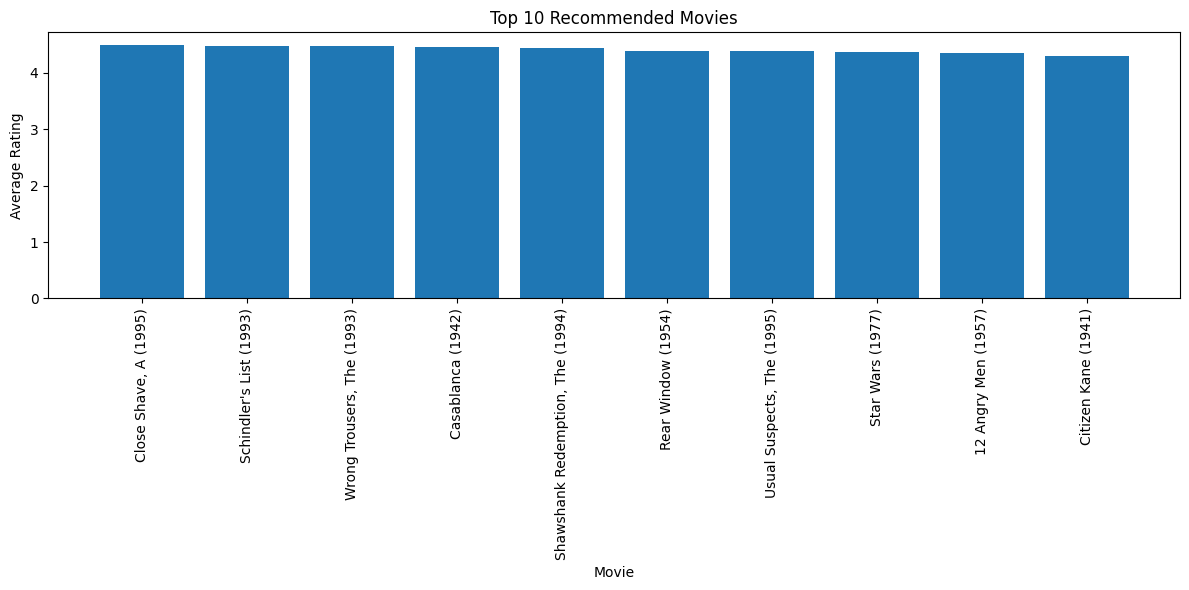

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.bar(
    best_movies.head(10).index,
    best_movies.head(10)["Average_Rating"]
)

plt.xticks(rotation=90)

plt.xlabel("Movie")

plt.ylabel("Average Rating")

plt.title("Top 10 Recommended Movies")

plt.tight_layout()

plt.show()

## Step 4: Improved Popularity-Based Recommendation

Ranking movies solely by the number of ratings may promote frequently watched but average-quality movies.

To generate more reliable recommendations:

- Movies with fewer than 100 ratings are filtered out.
- Remaining movies are ranked by their average rating.

This simple strategy produces a stronger baseline recommendation system by balancing popularity with quality.